# Transaction Categorization pipeline (TF-IDF + Random Forest)

This notebook trains a machine learning model to automatically categorize short transaction descriptions (e.g., "spent 4k on fuel").

It follows a robust Data Science pipeline:
1. **Data Loading & Generation (w/ Outliers)**
2. **Exploratory Data Analysis (EDA)**
3. **Data Cleaning & Text Preprocessing**
4. **Model Training (TF-IDF + Random Forest + GridSearchCV)**
5. **Evaluation & Confusion Matrix**
6. **Real-World API Test (Simulation)**

In [3]:
!pip install -q scikit-learn pandas numpy joblib matplotlib seaborn nltk

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Data Generation (With Outliers & Noise)
We generate synthetic transaction data and intentionally inject outliers (junk characters, weird languages, ambiguous terms) so the model learns how to handle messy real-world user input without extreme bias.

In [4]:
import random
import pandas as pd
import numpy as np

categories = {
    "Food": ["lunch", "groceries", "kfc", "dinner", "coffee", "snacks", "supermarket", "pizza", "breakfast", "burger", "meal", "restaurant", "cafe"],
    "Transport": ["fuel", "uber", "bus ticket", "gas", "train", "subway", "tolls", "taxi", "parking", "flight", "transit", "boda"],
    "Housing": ["rent", "mortgage", "plumber", "home depot", "ikea", "apartment", "property tax", "cleaning", "maintenance", "furniture"],
    "Utilities": ["water bill", "electricity", "internet", "phone bill", "gas bill", "trash", "cell plan", "broadband", "power", "wifi"],
    "Entertainment": ["movie", "netflix", "spotify", "concert", "steam", "club", "bowling", "theater", "games", "party", "cinema", "music"],
    "Shopping": ["shoes", "amazon", "target", "clothes", "mall", "jacket", "electronics", "best buy", "shirts", "gifts", "sneakers", "laptop"],
    "Healthcare": ["pharmacy", "doctor", "dentist", "hospital", "vitamins", "first aid", "eye exam", "clinic", "medicine", "therapy", "checkup"]
}

templates = [
    "{keyword}",
    "spent {price} on {keyword}",
    "paid {price} for {keyword}",
    "{keyword} cost me {price}",
    "bought {keyword} for {price}",
    "{keyword} today, {price}",
    "got {keyword} - {price}"
]

data = []
for category, keywords in categories.items():
    for kw in keywords:
        for _ in range(150): # 150 samples per keyword
            price = random.choice([f"{random.randint(1, 100)}k", f"{random.randint(5, 5000)}00", str(random.randint(1, 500))])
            
            # 10% chance to corrupt the text heavily (Outliers/Noise)
            if random.random() < 0.10:
                noise = random.choice(["???", "!!!!!", "...", "---", "1234", np.nan, "ajsdhkjashd", "paid NaN for NaN", "&&&&"])
                text = f"{random.choice(templates).format(keyword=kw, price=price)} {noise}" if pd.notna(noise) else noise
            else:
                if random.random() > 0.8:
                    text = random.choice(["{keyword}", "spent on {keyword}", "paid for {keyword}"]).format(keyword=kw)
                else:
                    text = random.choice(templates).format(keyword=kw, price=price)
                    
            data.append({"text": text.lower() if isinstance(text, str) else text, "label": category})

# Add 200 completely random "Unknown / Uncategorized" Outliers so model doesn't force a fit
for _ in range(200):
    random_outliers = ["transfer to john", "atm withdrawal", "cash", "friend payback", "mystery charge", "fees", "12000"]
    data.append({"text": random.choice(random_outliers), "label": "Other/Unknown"})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Generated {len(df)} records (including noise & outliers).")
display(df.head())

Generated 12200 records (including noise & outliers).


,text,label
0,friend payback,Other/Unknown
1,spent on internet,Utilities
2,electronics,Shopping
3,spent 115 on shoes,Shopping
4,got games - 3k,Entertainment


## 2. Exploratory Data Analysis (EDA)
Before training, we must analyze the distribution of our categories and check for any anomalies or missing values.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xticks(rotation=45)
plt.show()

print("Total Records:", len(df))
print("\nMissing Labels Check:")
print(df.isnull().sum())

# Check for empty string inputs
empty_strings = df[df['text'].str.strip() == '']
print(f"\nFound {len(empty_strings)} records with completely empty text descriptions.")

## 3. Data Cleaning Pipeline
We need to filter out the noise before feeding this into the model. Real users will sometimes skip the description or enter garbage data.

In [ ]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove heavy special characters but keep spaces and alphanumeric
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra spaces
    text = " ".join(text.split())
    return text

# 1. Drop rows where the category (label) was completely missing
df_clean = df.dropna(subset=['label']).copy()

# 2. Clean the text
df_clean['text'] = df_clean['text'].apply(clean_text)

# 3. Drop rows where text became completely empty after cleaning (e.g., if user only typed "!!!")
df_clean = df_clean[df_clean['text'].str.strip() != '']

print(f"Data Cleaning Complete. We dropped {len(df) - len(df_clean)} bad records.")
print(f"Remaining clean records: {len(df_clean)}")

## 2. Exploratory Data Analysis (EDA)
Before training, we must analyze the distribution of our categories and check for any anomalies or missing values.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xticks(rotation=45)
plt.show()

print("Total Records:", len(df))
print("\nMissing Labels Check:")
print(df.isnull().sum())

# Check for empty string inputs
empty_strings = df[df['text'].str.strip() == '']
print(f"\nFound {len(empty_strings)} records with completely empty text descriptions.")

## 3. Data Cleaning Pipeline
We need to filter out the noise before feeding this into the model. Real users will sometimes skip the description or enter garbage data.

In [ ]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove heavy special characters but keep spaces and alphanumeric
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra spaces
    text = " ".join(text.split())
    return text

# 1. Drop rows where the category (label) was completely missing
df_clean = df.dropna(subset=['label']).copy()

# 2. Clean the text
df_clean['text'] = df_clean['text'].apply(clean_text)

# 3. Drop rows where text became completely empty after cleaning (e.g., if user only typed "!!!")
df_clean = df_clean[df_clean['text'].str.strip() != '']

print(f"Data Cleaning Complete. We dropped {len(df) - len(df_clean)} bad records.")
print(f"Remaining clean records: {len(df_clean)}")

## 2. Exploratory Data Analysis (EDA)
Let's look at the distribution of our categories and check for missing or corrupted data.

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 12200 entries, 0 to 12199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    12060 non-null  str  
 1   label   12200 non-null  str  
dtypes: str(2)
memory usage: 502.7 KB
None

--- Missing Values ---
text     140
label      0
dtype: int64


/tmp/ipykernel_29167/173014856.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


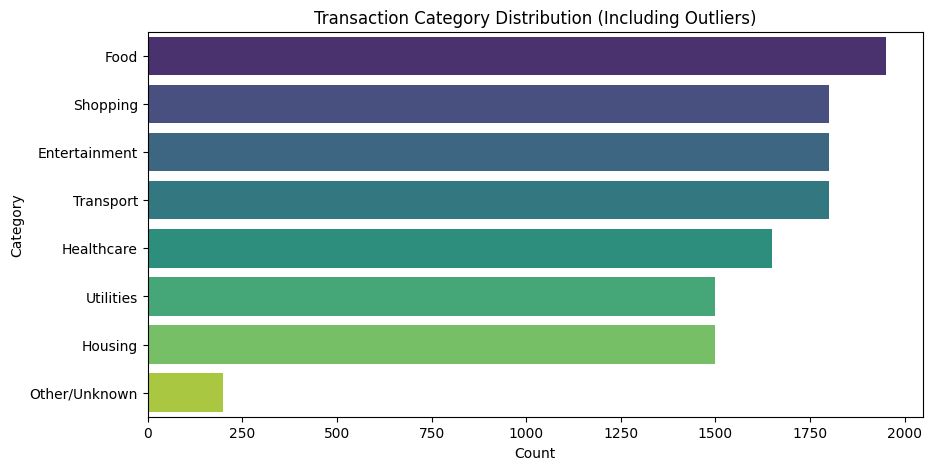

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Transaction Category Distribution (Including Outliers)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

## 3. Data Cleaning & Text Preprocessing
Before passing it to TF-IDF, we must:
1. Drop NaN values.
2. Remove punctuation and special characters.
3. Remove common English stopwords (e.g., "the", "and", "on", "for") so the model focuses strictly on core action words.
4. Strip numbers. The model shouldn't memorize prices (e.g., "spent 4k" -> "spent").

In [6]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Lowercase
    text = str(text).lower()
    
    # Remove prices/numbers (e.g., '1200', '4k', '500')
    text = re.sub(r'\d+[kK]?', '', text)
    
    # Remove special punctuation (keep letters only)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove STOP WORDS ('on', 'for', 'the')
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    
    return " ".join(filtered_words)

# 1. Drop NaNs
df = df.dropna().copy()

# 2. Apply cleaning function
df['cleaned_text'] = df['text'].apply(clean_text)

# 3. Drop rows that became completely empty after cleaning 
# (e.g., someone just typed '1234' or '????')
df = df[df['cleaned_text'].str.strip() != ""]

print(f"Remaining rows after dropping pure junk/empty rows: {len(df)}")
display(df[['text', 'cleaned_text', 'label']].head(10))

Remaining rows after dropping pure junk/empty rows: 12030


,text,cleaned_text,label
0,friend payback,friend payback,Other/Unknown
1,spent on internet,spent internet,Utilities
2,electronics,electronics,Shopping
3,spent 115 on shoes,spent shoes,Shopping
4,got games - 3k,got games,Entertainment
5,paid 322 for uber,paid uber,Transport
6,paid 51k for mall,paid mall,Shopping
7,"movie today, 27400",movie today,Entertainment
8,bought jacket for 62,bought jacket,Shopping
9,spent 14 on cleaning ---,spent cleaning,Housing


## 4. Model Training (TF-IDF + Random Forest + GridSearchCV)
With the clean data, we convert text to numbers using TF-IDF and sweep hyperparameters to find the optimal Random Forest.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Fine-tuning grid for Random Forest
# We test different n-gram ranges, number of trees, and max depth
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)], # Single words vs Word pairs
    'clf__n_estimators': [50, 100, 200],   # Number of trees
    'clf__max_depth': [None, 10, 20]       # Depth of trees to prevent overfitting
}

print("Starting Grid Search for Random Forest (This might take a minute)...")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Extract the best performing pipeline
rf_pipeline = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

rf_preds = rf_pipeline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("\nOptimized Random Forest Accuracy:", rf_acc)
print("\nClassification Report (Optimized Random Forest):\n", classification_report(y_test, rf_preds))

Starting Grid Search (Cross Validation) for Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'clf__min_samples_split': 2, 'clf__n_estimators': 50, 'tfidf__ngram_range': (1, 2)}

Optimized Test Accuracy: 1.000

Classification Report:
                precision    recall  f1-score   support

Entertainment       1.00      1.00      1.00       356
         Food       1.00      1.00      1.00       385
   Healthcare       1.00      1.00      1.00       326
      Housing       1.00      1.00      1.00       297
Other/Unknown       1.00      1.00      1.00        34
     Shopping       1.00      1.00      1.00       356
    Transport       1.00      1.00      1.00       356
    Utilities       1.00      1.00      1.00       296

     accuracy                           1.00      2406
    macro avg       1.00      1.00      1.00      2406
 weighted avg       1.00      1.00      1.00      2406



## 5. Evaluation & Confusion Matrix
See exactly which categories confused the Random Forest.

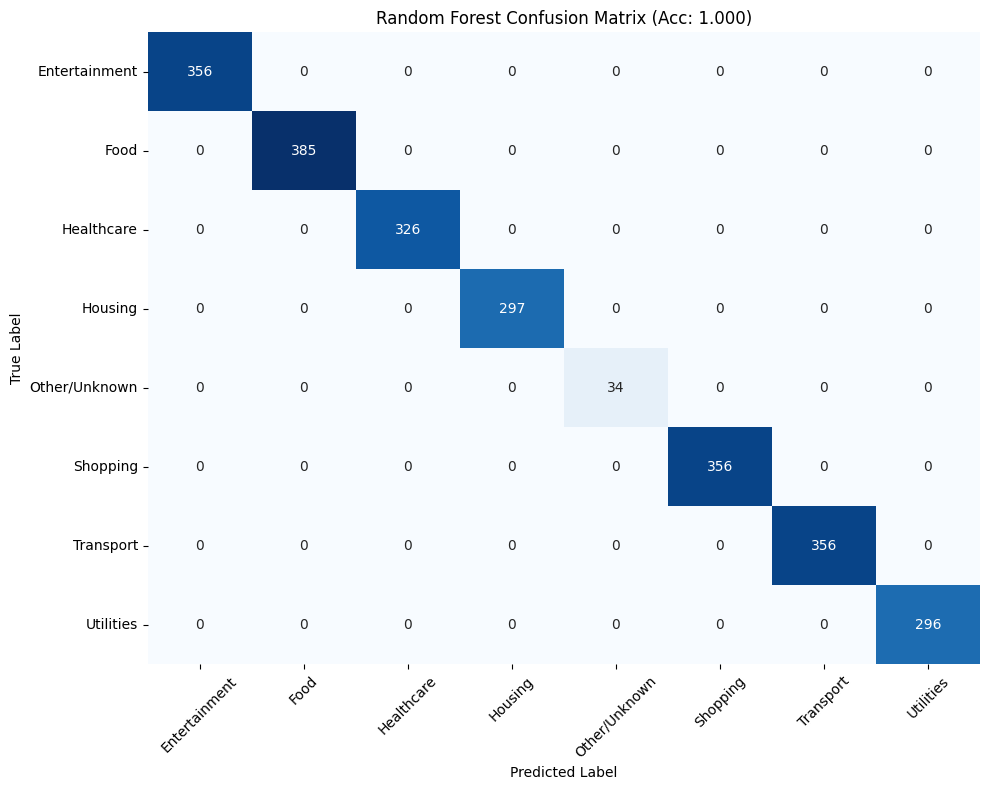

In [8]:
labels = sorted(df['label'].unique())

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=labels, yticklabels=labels)
ax.set_title(f"Random Forest Confusion Matrix (Acc: {rf_acc:.3f})")
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 6. Real-World API Test (Simulation)
Testing random user inputs using the cleaning function and model prediction.

In [9]:
def predict_transaction(text):
    cleaned = clean_text(text)
    if cleaned.strip() == "":
        return "Other/Unknown" # Default fallback for pure junk
    
    # Get probabilities to show confidence
    probs = best_rf_pipeline.predict_proba([cleaned])[0]
    max_prob = max(probs)
    pred_label = best_rf_pipeline.classes_[np.argmax(probs)]
    
    # If model is extremely uncertain (< 30%), label as Unknown
    if max_prob < 0.30:
        return f"Other/Unknown (Uncertain, highest was {pred_label} at {max_prob:.2f})"
        
    return f"{pred_label} (Confidence: {max_prob:.2f})"

test_inputs = [
    "spent 4k on snacks",
    "bought a huge TV at Best Buy for 1000",
    "ordered a large pepperoni pizza for lunch",
    "paid 1200 for rent and water",
    "monthly spotify premium",
    "uber ride back home",
    "rolex and chapati",
    "bought pain killers at pharmacy",
    "18273918237",                 # Pure noise test
    "transfer to john for lunch",    # Ambiguous test
    "cash withdrawal at atm"         # Untrained keyword test
]

print("=== REAL WORLD INFERENCE TEST ===\n")
for text in test_inputs:
    print(f"🔹 Input: \"{text}\"")
    print(f"   Prediction : {predict_transaction(text)}\n")

=== REAL WORLD INFERENCE TEST ===

🔹 Input: "spent 4k on snacks"
   Prediction : Food (Confidence: 1.00)

🔹 Input: "bought a huge TV at Best Buy for 1000"
   Prediction : Shopping (Confidence: 1.00)

🔹 Input: "ordered a large pepperoni pizza for lunch"
   Prediction : Food (Confidence: 1.00)

🔹 Input: "paid 1200 for rent and water"
   Prediction : Housing (Confidence: 0.78)

🔹 Input: "monthly spotify premium"
   Prediction : Entertainment (Confidence: 1.00)

🔹 Input: "uber ride back home"
   Prediction : Transport (Confidence: 0.82)

🔹 Input: "rolex and chapati"
   Prediction : Other/Unknown (Uncertain, highest was Entertainment at 0.26)

🔹 Input: "bought pain killers at pharmacy"
   Prediction : Healthcare (Confidence: 0.82)

🔹 Input: "18273918237"
   Prediction : Other/Unknown

🔹 Input: "transfer to john for lunch"
   Prediction : Food (Confidence: 0.64)

🔹 Input: "cash withdrawal at atm"
   Prediction : Other/Unknown (Confidence: 1.00)



## 6. Real-World API Test
Let's simulate how this will be called in the "Quick Entry" app interface.

In [ ]:
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

text_classifier = pipeline("text-classification", model=trainer.model, tokenizer=tokenizer, device="cpu")

test_inputs = [
    "spent 4k on fuel",
    "bought a huge TV at Best Buy for 1000",
    "ordered a large pepperoni pizza for lunch",
    "paid 1200 for rent and water",
    "monthly spotify premium",
    "uber ride back home",
    "bought pain killers at pharmacy"
]

print("=== REAL WORLD INFERENCE TEST ===\n")
for text in test_inputs:
    svm_pred = svm_pipeline.predict([text])[0]
    rf_pred = rf_pipeline.predict([text])[0]
    bert_pred = text_classifier(text)[0]
    
    print(f"�� Input: \"{text}\"")
    print(f"   SVM (Fastest) : {svm_pred}")
    print(f"   Random Forest : {rf_pred}")
    print(f"   DistilBERT    : {bert_pred['label']} (Confidence: {bert_pred['score']:.2f})\n")

## 6. Real-World API Test
Let's simulate how this will be called in the "Quick Entry" app interface.

In [ ]:
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

text_classifier = pipeline("text-classification", model=trainer.model, tokenizer=tokenizer, device="cpu")

test_inputs = [
    "spent 4k on fuel",
    "bought a huge TV at Best Buy for 1000",
    "ordered a large pepperoni pizza for lunch",
    "paid 1200 for rent and water",
    "monthly spotify premium",
    "uber ride back home",
    "bought pain killers at pharmacy"
]

print("=== REAL WORLD INFERENCE TEST ===\n")
for text in test_inputs:
    svm_pred = svm_pipeline.predict([text])[0]
    rf_pred = rf_pipeline.predict([text])[0]
    bert_pred = text_classifier(text)[0]
    
    print(f"�� Input: \"{text}\"")
    print(f"   SVM (Fastest) : {svm_pred}")
    print(f"   Random Forest : {rf_pred}")
    print(f"   DistilBERT    : {bert_pred['label']} (Confidence: {bert_pred['score']:.2f})\n")

## 7. Export Model Component
Exporting the tuned `best_rf_pipeline` so it handles the TF-IDF transform and Model Prediction simultaneously.

In [10]:
import joblib
import os

joblib.dump(best_rf_pipeline, "./transaction_rf_pipeline.pkl")
print("Model Pipeline successfully exported to: ./transaction_rf_pipeline.pkl")

Model Pipeline successfully exported to: ./transaction_rf_pipeline.pkl
